# Binary Classification U-Net for Brain Tumor Detection

- The model outputs two logits per input, which are converted via Softmax into probabilities for the classes ["no tumor", "tumor"].

In [1]:
from src.brain_tumor_semantic_segmentation.data import load_mri_dataframe, get_dataloader_binarytransformed


df = load_mri_dataframe()
cls_train_loader, cls_val_loader = get_dataloader_binarytransformed(df, batch_size=8, augment=False)

print(f"Train Samples: {len(cls_train_loader.dataset)} | Val Samples: {len(cls_val_loader.dataset)}")

Loading cached dataset stats from 'mri_dataset_stats.npy'
Dataset Mean: [0.0919 0.0833 0.0875]
Dataset Std:  [0.1354 0.1238 0.1293]
[Data] (Binary) Train samples: 3339 ; Val samples: 590
Train Samples: 3339 | Val Samples: 590


In [2]:
import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

class VGG16(nn.Module):
    """
    VGG16-based classification model for brain tumor detection.
    
    Outputs:
        pre-Softmax scores (logits) for no tumor/tumor classes
    """
    def __init__(self, dropout_prob=0.3, freeze_features=True):
        super().__init__()
        base = vgg16(weights=VGG16_Weights.DEFAULT)
        self.features = base.features
        self.avgpool  = base.avgpool

        if freeze_features:
            for p in self.features.parameters():
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
   
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        logits = self.classifier(x)

        return logits

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

model = VGG16(freeze_features=True)
print("Number of Parameters (Classification, no augment):", sum(p.numel() for p in model.parameters()))
model.to(device)
print(f"Device: {device}.")

Number of Parameters (Classification, no augment): 21203778
Device: cuda.


In [4]:
import torch.optim as optim
from src.brain_tumor_semantic_segmentation.train_generalized import train


trained_model, training_results = train(
    model,
    cls_train_loader,
    cls_val_loader,
    device,
    epochs=60,
    lr=1e-3,
    optimizer_class=optim.Adam,
    loss_fn = nn.CrossEntropyLoss,
    task="classification",
    save_name="binary_classification_model"
)



Epoch 1/60: 100%|███████████████████████████████| 418/418 [00:17<00:00, 24.52it/s, train_acc=0.7766, train_loss=0.5140]


Epoch 1/60 - Avg Train Loss: 0.5140


Epoch 2/60: 100%|███████████████████████████████| 418/418 [00:17<00:00, 24.54it/s, train_acc=0.8488, train_loss=0.3224]


Epoch 2/60 - Avg Train Loss: 0.3224


Epoch 3/60: 100%|███████████████████████████████| 418/418 [00:16<00:00, 24.63it/s, train_acc=0.8883, train_loss=0.2500]


...

Epoch 58/60 - Avg Train Loss: 0.0564


Epoch 59/60: 100%|██████████████████████████████| 418/418 [00:17<00:00, 23.78it/s, train_acc=0.9895, train_loss=0.0240]


Epoch 59/60 - Avg Train Loss: 0.0240


Epoch 60/60: 100%|██████████████████████████████| 418/418 [00:17<00:00, 24.15it/s, train_acc=0.9874, train_loss=0.0336]


Epoch 60/60 - Avg Train Loss: 0.0336


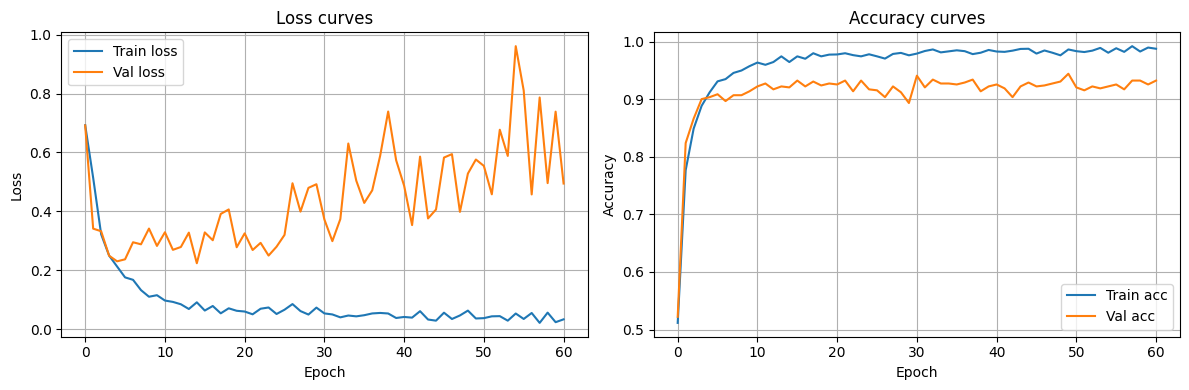

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67864704..2.6809561].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67864704..-0.5463057].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67864704..6.263284].


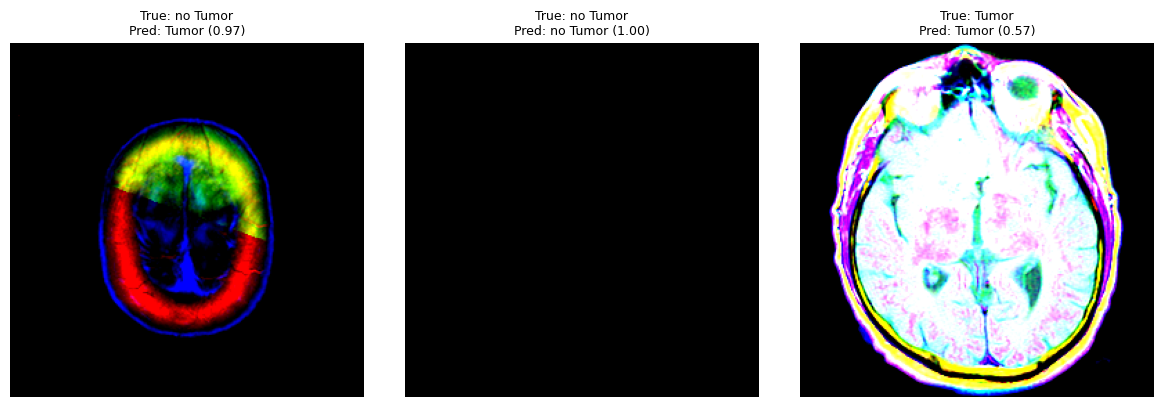

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67864704..6.6116815].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67864704..5.281436].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67864704..4.571086].


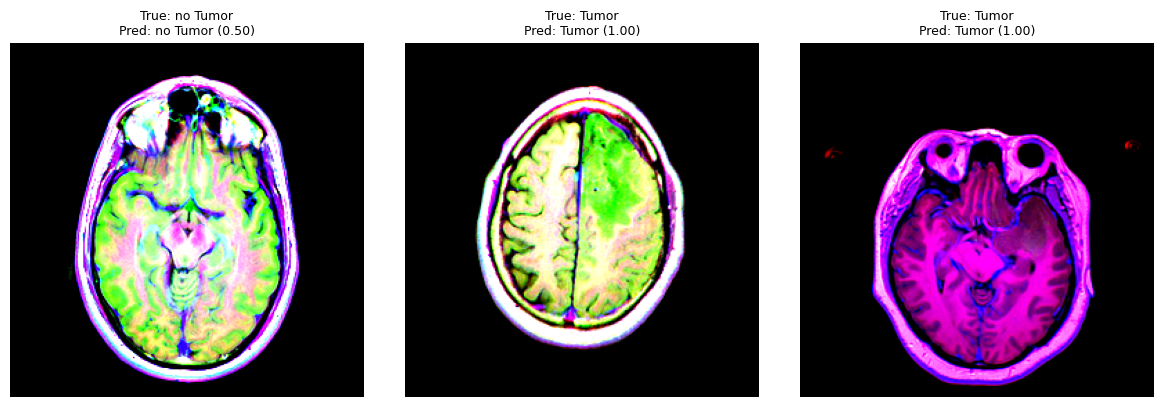

Final Val Accuracy: 0.9322


In [5]:
from src.brain_tumor_semantic_segmentation.evaluate import evaluate_classification 
class_names = ["no Tumor", "Tumor"]
evaluate_classification(
    results=training_results,
    num_batches=2,
    class_names=class_names
)